In [1]:
import anndata

import dtangle

In [2]:
# Load dataset
adata_mix = anndata.read_h5ad("./data/brain_aging_microarray.h5ad")
adata_ref = anndata.read_h5ad("./data/brain_single_cell.h5ad")
adata_mix.var_names_make_unique()
adata_ref.var_names_make_unique()

/home/malte/Dokumente/Github/dtangle/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
# Find common genes
common_genes = adata_mix.var_names.intersection(adata_ref.var_names)
adata_mix = adata_mix[:, common_genes].copy()
adata_ref = adata_ref[:, common_genes].copy()

In [6]:
dtangle.deconvolut(
    adata_mix,
    references=adata_ref,
    reference_annotation_col="cell_type",
    data_type="microarray-gene",
    key_added="dtangle_sc",
)

adata_mix.obsm["dtangle_sc"].head()

,Oligodendrocyte precursor cells,Neurons,Neuroblast,Astrocytes,Oligodendrocytes,Microglia
GSM1303144_24M.CEL,0.130750,0.385471,0.157636,0.128135,0.087965,0.110044
GSM1303145_25BF.CEL,0.134050,0.373632,0.158939,0.135272,0.088278,0.109829
GSM1303146_25F.CEL,0.131120,0.372604,0.154251,0.146045,0.091005,0.104975
GSM1303147_26BM.CEL,0.129604,0.356444,0.152652,0.157790,0.091801,0.111709
GSM1303148_26M.CEL,0.129315,0.357495,0.153784,0.141635,0.101902,0.115869


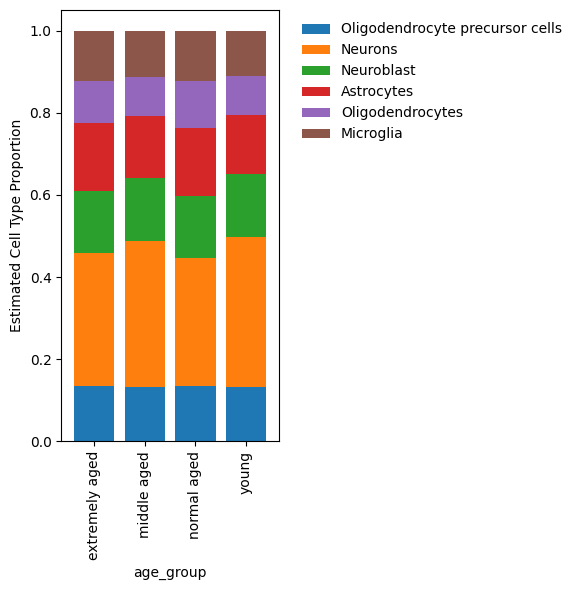

In [7]:
import matplotlib.pyplot as plt

proportions = adata_mix.obsm["dtangle_sc"].copy()
proportions["age_group"] = adata_mix.obs["age_group"].values
proportions = proportions.groupby("age_group", observed=True).mean()
proportions.plot(kind="bar", stacked=True, figsize=(6, 6), width=0.8)
plt.ylabel("Estimated Cell Type Proportion")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8545/2919019503.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


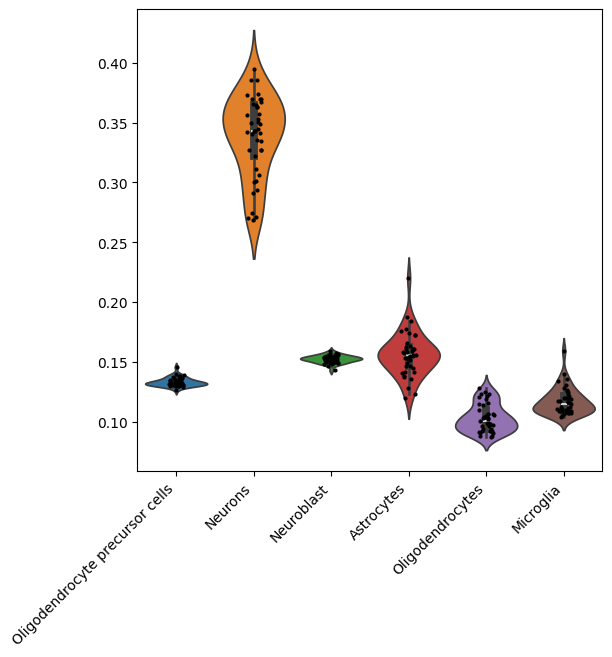

In [9]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 6))
sns.violinplot(adata_mix.obsm["dtangle_sc"], ax=ax)
sns.stripplot(adata_mix.obsm["dtangle_sc"], color="k", size=3, ax=ax)
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")